## Causality and Randomized Controlled Trials

In [99]:
from datascience import *
import numpy as np

import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
%matplotlib inline
bta = Table.read_table('bta-1.csv')
bta

Group,Result
Control,1
Control,1
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0


In [100]:
bta.group('Group', np.mean)

Group,Result mean
Control,0.125
Treatment,0.6


In [101]:
bta.group('Group', np.average)

Group,Result average
Control,0.125
Treatment,0.6


In [102]:
#The code you've provided calculates the observed distance (or absolute difference) between the average values of two groups in a dataset. 
observed_proportions = bta.group('Group', np.average).column(1)
observed_distance = abs(observed_proportions.item(0) - observed_proportions.item(1))
observed_distance

0.475

In [118]:
shuffled_labels = bta.sample(with_replacement=False).column(0)
shuffled_labels

array(['Control', 'Treatment', 'Control', 'Control', 'Control',
       'Treatment', 'Control', 'Control', 'Treatment', 'Control',
       'Treatment', 'Control', 'Treatment', 'Treatment', 'Treatment',
       'Control', 'Treatment', 'Control', 'Treatment', 'Treatment',
       'Treatment', 'Control', 'Treatment', 'Control', 'Treatment',
       'Control', 'Control', 'Treatment', 'Control', 'Treatment', 'Control'],
      dtype='<U9')

In [119]:
bta_with_shuffled_labels = bta.with_column('Shuffled Label', shuffled_labels)
bta_with_shuffled_labels.show()

Group,Result,Shuffled Label
Control,1,Control
Control,1,Treatment
Control,0,Control
Control,0,Control
Control,0,Control
Control,0,Treatment
Control,0,Control
Control,0,Control
Control,0,Treatment
Control,0,Control


In [120]:
def distance(tbl, label_col):
    props = tbl.group(label_col, np.average).column(2)
    print(props)
    return abs(props.item(0) - props.item(1))

distance(bta_with_shuffled_labels, 'Shuffled Label')

[ 0.25        0.46666667]


0.21666666666666667

In [106]:
def one_simulated_distance():
    shuffled_labels = bta.sample(with_replacement = False
                                                    ).column('Group')
    shuffled_table = bta.select('Result').with_column(
        'Shuffled Label', shuffled_labels)
    return distance(shuffled_table, 'Shuffled Label') 

In [107]:
distances = make_array()

repetitions = 20000
for i in np.arange(repetitions):
    new_distance = one_simulated_distance()
    distances = np.append(distances, new_distance)

[ 0.1875      0.53333333]
[ 0.3125  0.4   ]
[ 0.375       0.33333333]
[ 0.375       0.33333333]
[ 0.375       0.33333333]
[ 0.125  0.6  ]
[ 0.3125  0.4   ]
[ 0.25        0.46666667]
[ 0.375       0.33333333]
[ 0.25        0.46666667]
[ 0.375       0.33333333]
[ 0.4375      0.26666667]
[ 0.25        0.46666667]
[ 0.1875      0.53333333]
[ 0.1875      0.53333333]
[ 0.375       0.33333333]
[ 0.25        0.46666667]
[ 0.375       0.33333333]
[ 0.3125  0.4   ]
[ 0.375       0.33333333]
[ 0.3125  0.4   ]
[ 0.375       0.33333333]
[ 0.375       0.33333333]
[ 0.375       0.33333333]
[ 0.3125  0.4   ]
[ 0.25        0.46666667]
[ 0.375       0.33333333]
[ 0.3125  0.4   ]
[ 0.375       0.33333333]
[ 0.3125  0.4   ]
[ 0.375       0.33333333]
[ 0.3125  0.4   ]
[ 0.375       0.33333333]
[ 0.3125  0.4   ]
[ 0.375       0.33333333]
[ 0.375       0.33333333]
[ 0.4375      0.26666667]
[ 0.375       0.33333333]
[ 0.375       0.33333333]
[ 0.1875      0.53333333]
[ 0.4375      0.26666667]
[ 0.25        0.

In [108]:
def abs_difference_in_means(tbl):
    proportions = tbl.group('Group', np.average).column(1)
    return abs(proportions.item(0) - proportions.item(1))

abs_difference_in_means(bta)

0.475

Observed statistic: 0.475
P-value: 0.012


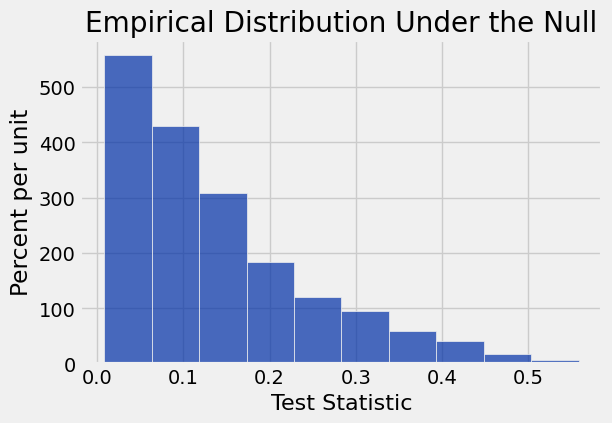

In [109]:
t = bta.select('Group', 'Result')
observed = abs_difference_in_means(t)
repetitions = 1000
    
# Assuming the null is true, randomly permute the variable 
# and collect all the generated test statistics
stats = make_array()
for i in np.arange(repetitions):
    simulated_results = t.select('Result').sample()
    simulated_groups = t.select('Group').sample(with_replacement=False)
    simulated_outcomes = Table().with_column('Group', simulated_groups.column(0)).with_column('Result', simulated_results.column(0))
    simulated_stat = abs_difference_in_means(simulated_outcomes)
    stats = np.append(stats, simulated_stat)
    
# Find the empirical P-value:
p = np.count_nonzero(stats >= observed) / repetitions

# Draw the empirical histogram of the test statistic
# generated based on the null hypothesis,
# and compare with the value observed in the original sample
Table().with_column('Test Statistic', stats).hist()
plots.title('Empirical Distribution Under the Null')
print('Observed statistic:', observed)
print('P-value:', p)

## Alternative Test: Permutation Tests

In [110]:
def difference_in_means(t):
    means = t.group(0, np.mean)
    return means.column(1).item(0) - means.column(1).item(1)

difference_in_means(smoke_weight)

NameError: name 'smoke_weight' is not defined

In [ ]:
def permutation_test_means(table, variable, classes, repetitions, unit=None):
    """Test whether two numerical samples 
    come from the same underlying distribution, 
    using the absolute difference between the means.
    table: name of table containing the sample
    variable: label of column containing the numerical variable 
    classes: label of column containing names of the two samples
    repetitions: number of random permutations
    
    variable -- Label for a numerical variable in table
    classes -- Label for a two-category (A & B) variable in table
    """
    
    t = table.select(classes, variable)
    observed = abs(difference_in_means(t))
    
    # Assuming the null is true, randomly permute the variable 
    # and collect all the generated test statistics
    stats = make_array()
    for i in np.arange(repetitions):
        shuffled_var = t.select(variable).sample(with_replacement=False).column(0)
        shuffled = t.select(classes).with_column('Shuffled Variable', shuffled_var)
        new_stat = abs(difference_in_means(shuffled))
        stats = np.append(stats, new_stat)
    
    # Find the empirical P-value:
    p = np.count_nonzero(stats >= observed) / repetitions

    # Draw the empirical histogram of the tvd's generated under the null, 
    # and compare with the value observed in the original sample
    Table().with_column('Test Statistic', stats).hist(unit=unit)
    plots.title('Empirical Distribution Under the Null')
    print('Observed statistic:', observed)
    print('Empirical P-value:', p)

In [ ]:
permutation_test_means(baby, 'Birth Weight', 'Maternal Smoker', 1000, 'ounce')

In [ ]:
permutation_test_means(bta, 'Result', 'Group', 1000)

Because the trials were randomized, we can confidently say the treatment caused the difference in outcomes, as random assignment eliminates confounding variables that might otherwise influence the result. Without randomization, the test might still show an association, but it wouldn't prove causality. For instance, if patients chose their treatment, those in more pain might be more likely to pick it, creating a false link between treatment and pain relief due to pre-existing pain.